In [1]:
"""
SVM Binary Classification — Customer Churn
Dataset : churn-bigml-80.csv
Objectives:
  - Train SVM with Linear and RBF kernels
  - Visualize decision boundary (2-D PCA projection)
  - Evaluate: Accuracy, Precision, Recall, F1, AUC-ROC
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. LOAD & PREPROCESS

In [2]:
df = pd.read_csv("/content/churn-bigml-80.csv")

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=["object", "bool"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(columns=["Churn"])
y = df["Churn"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Class distribution (test) — 0: {(y_test==0).sum()}, 1: {(y_test==1).sum()}\n")

Train: 2132 samples | Test: 534 samples
Class distribution (test) — 0: 456, 1: 78



## 2. TRAIN SVMs

In [3]:
kernels = {
    "Linear": SVC(kernel="linear", probability=True, random_state=42, class_weight="balanced"),
    "RBF"   : SVC(kernel="rbf",    probability=True, random_state=42, C=1.0, gamma="scale", class_weight="balanced"),
}

results = {}
for name, clf in kernels.items():
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_prob  = clf.predict_proba(X_test)[:, 1]

    results[name] = {
        "clf"       : clf,
        "y_pred"    : y_pred,
        "y_prob"    : y_prob,
        "accuracy"  : accuracy_score(y_test, y_pred),
        "precision" : precision_score(y_test, y_pred),
        "recall"    : recall_score(y_test, y_pred),
        "f1"        : f1_score(y_test, y_pred),
        "auc"       : roc_auc_score(y_test, y_prob),
    }
    print(f"{'='*45}")
    print(f"  Kernel : {name}")
    print(f"  Accuracy  : {results[name]['accuracy']:.4f}")
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")
    print(f"  F1-Score  : {results[name]['f1']:.4f}")
    print(f"  AUC-ROC   : {results[name]['auc']:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Churn','Churn'])}")

  Kernel : Linear
  Accuracy  : 0.7528
  Precision : 0.3312
  Recall    : 0.6795
  F1-Score  : 0.4454
  AUC-ROC   : 0.7582

              precision    recall  f1-score   support

    No Churn       0.93      0.77      0.84       456
       Churn       0.33      0.68      0.45        78

    accuracy                           0.75       534
   macro avg       0.63      0.72      0.64       534
weighted avg       0.85      0.75      0.78       534

  Kernel : RBF
  Accuracy  : 0.8783
  Precision : 0.5747
  Recall    : 0.6410
  F1-Score  : 0.6061
  AUC-ROC   : 0.8558

              precision    recall  f1-score   support

    No Churn       0.94      0.92      0.93       456
       Churn       0.57      0.64      0.61        78

    accuracy                           0.88       534
   macro avg       0.76      0.78      0.77       534
weighted avg       0.88      0.88      0.88       534



## 3. PCA → 2-D for decision boundary

In [4]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
X_test_2d  = pca.transform(X_test)

# Re-train on 2-D for boundary plot
clf_lin_2d = SVC(kernel="linear", probability=True, random_state=42, class_weight="balanced")
clf_rbf_2d = SVC(kernel="rbf",    probability=True, random_state=42, C=1.0, gamma="scale", class_weight="balanced")
clf_lin_2d.fit(X_train_2d, y_train)
clf_rbf_2d.fit(X_train_2d, y_train)

def plot_decision_boundary(ax, clf, X_2d, y, title):
    """Shade decision regions and scatter test points."""
    h = 0.04
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.contour(xx, yy, Z, colors="k", linewidths=0.6, linestyles="--")

    colors = ["#4e79a7", "#e15759"]
    labels = ["No Churn", "Churn"]
    for cls, col, lbl in zip([0, 1], colors, labels):
        mask = (y == cls)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=col, label=lbl, alpha=0.55, s=18, edgecolors="k", linewidths=0.3)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("PCA Component 1", fontsize=10)
    ax.set_ylabel("PCA Component 2", fontsize=10)
    ax.legend(fontsize=9)

## 4. FIGURE — 2×3 layout Row 1 : Decision boundaries (Linear | RBF)  + Metric bar chart Row 2 : Confusion matrices (Linear | RBF)   + ROC curves

/tmp/ipykernel_10888/562120383.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


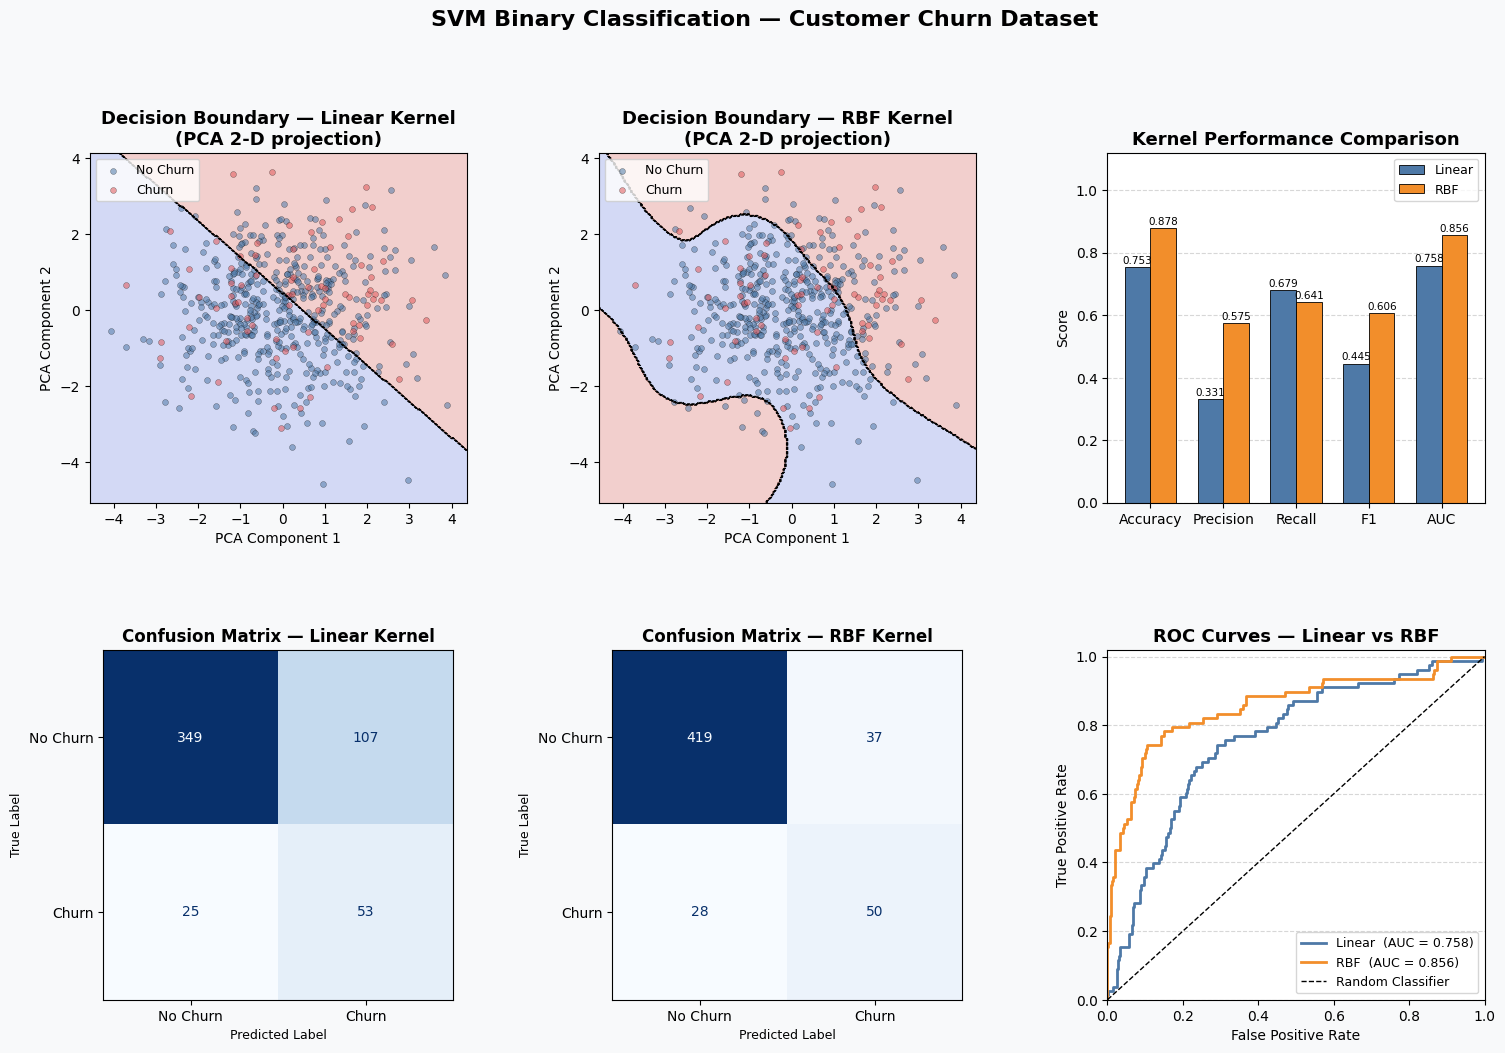

In [5]:
from IPython.display import display
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#f8f9fa")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_lin_db  = fig.add_subplot(gs[0, 0])
ax_rbf_db  = fig.add_subplot(gs[0, 1])
ax_metrics = fig.add_subplot(gs[0, 2])
ax_lin_cm  = fig.add_subplot(gs[1, 0])
ax_rbf_cm  = fig.add_subplot(gs[1, 1])
ax_roc     = fig.add_subplot(gs[1, 2])

for ax in [ax_lin_db, ax_rbf_db, ax_metrics, ax_lin_cm, ax_rbf_cm, ax_roc]:
    ax.set_facecolor("#ffffff")

# — Decision boundaries
plot_decision_boundary(ax_lin_db, clf_lin_2d, X_test_2d, y_test.values,
                       "Decision Boundary — Linear Kernel\n(PCA 2-D projection)")
plot_decision_boundary(ax_rbf_db, clf_rbf_2d, X_test_2d, y_test.values,
                       "Decision Boundary — RBF Kernel\n(PCA 2-D projection)")

# — Metric comparison bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
lin_vals = [results["Linear"][m.lower()] for m in metrics]
rbf_vals = [results["RBF"   ][m.lower()] for m in metrics]

x      = np.arange(len(metrics))
width  = 0.35
bars1  = ax_metrics.bar(x - width/2, lin_vals, width, label="Linear",
                         color="#4e79a7", edgecolor="k", linewidth=0.6)
bars2  = ax_metrics.bar(x + width/2, rbf_vals, width, label="RBF",
                         color="#f28e2b", edgecolor="k", linewidth=0.6)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax_metrics.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

ax_metrics.set_ylim(0, 1.12)
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(metrics, fontsize=10)
ax_metrics.set_ylabel("Score", fontsize=10)
ax_metrics.set_title("Kernel Performance Comparison", fontsize=13, fontweight="bold")
ax_metrics.legend(fontsize=9)
ax_metrics.yaxis.grid(True, linestyle="--", alpha=0.5)
ax_metrics.set_axisbelow(True)

# — Confusion matrices
for ax, name in [(ax_lin_cm, "Linear"), (ax_rbf_cm, "RBF")]:
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {name} Kernel", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=9)
    ax.set_ylabel("True Label", fontsize=9)

# — ROC curves
colors_roc = {"Linear": "#4e79a7", "RBF": "#f28e2b"}
for name in ["Linear", "RBF"]:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    auc_val      = results[name]["auc"]
    ax_roc.plot(fpr, tpr, color=colors_roc[name], lw=2,
                label=f"{name}  (AUC = {auc_val:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax_roc.set_xlim([0, 1])
ax_roc.set_ylim([0, 1.02])
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.set_title("ROC Curves — Linear vs RBF", fontsize=13, fontweight="bold")
ax_roc.legend(fontsize=9)
ax_roc.yaxis.grid(True, linestyle="--", alpha=0.5)
ax_roc.set_axisbelow(True)

# — Super-title
fig.suptitle("SVM Binary Classification — Customer Churn Dataset",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()

display(fig)
plt.show()